<a href="https://colab.research.google.com/github/Jags-08/cs-notes/blob/main/frequency-domain-filters-fourier-image-enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

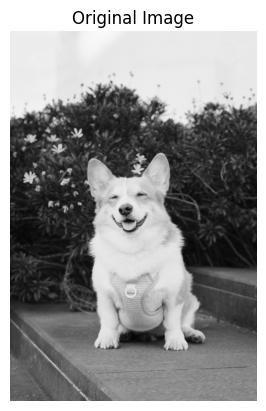

In [ ]:
# Install libraries
!pip install opencv-python ipywidgets

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import ipywidgets as widgets
from IPython.display import display

# Read image in grayscale
image = cv2.imread('/content/Lab5.jpg', 0)

plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

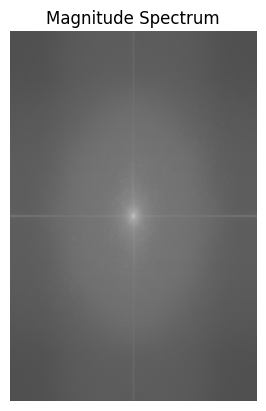

In [ ]:
# Fourier Transform
f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis('off')
plt.show()

rows, cols = image.shape
crow, ccol = rows//2, cols//2

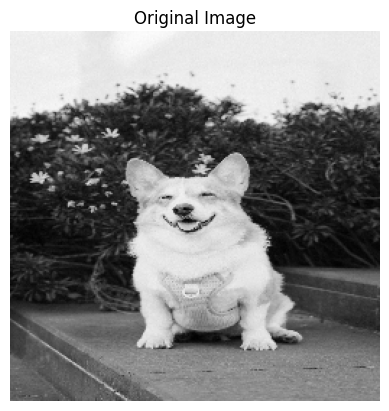

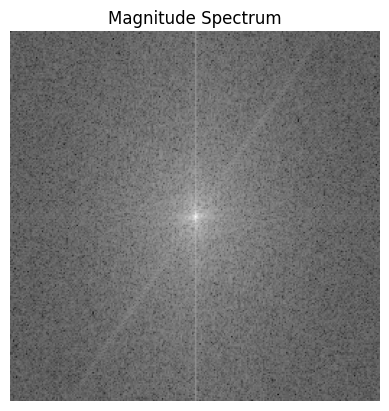

In [ ]:
# LAB 5 - Frequency Domain Processing

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from ipywidgets import interact, IntSlider

img = cv2.imread('/content/Lab5.jpg', 0)
img = cv2.resize(img, (256,256))

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# FFT
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude = 20*np.log(np.abs(fshift)+1)

plt.imshow(magnitude, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis('off')
plt.show()

In [ ]:
# IDEAL LOW PASS FILTER

def ideal_low_pass(D0, image_input):

    rows, cols = image_input.shape
    f = np.fft.fft2(image_input)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
    D = distance_matrix(rows, cols)

    mask = np.zeros((rows, cols))
    mask[D <= D0] = 1

    fshift_filtered = fshift * mask
    img_back = np.fft.ifft2(np.fft.ifftshift(fshift_filtered))
    img_back = np.abs(img_back)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(mask, cmap='gray')
    plt.title("LPF Mask")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(img_back, cmap='gray')
    plt.title(f"Filtered (D0={D0})")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title("Magnitude Spectrum")
    plt.axis('off')

    plt.show()


widgets.interact(ideal_low_pass,
                 D0=widgets.IntSlider(min=10, max=200, step=10, value=50),
                 image_input=widgets.fixed(image))

interactive(children=(IntSlider(value=50, description='D0', max=200, min=10, step=10), Output()), _dom_classes…

<function __main__.ideal_low_pass(D0, image_input)>

In [ ]:
# BUTTERWORTH LOW PASS

def butterworth_low_pass(D0, n, image_input):

    rows, cols = image_input.shape
    fshift = np.fft.fftshift(np.fft.fft2(image_input))
    D = distance_matrix(rows, cols)

    H = 1 / (1 + (D / D0)**(2*n))

    fshift_filtered = fshift * H
    img_back = np.fft.ifft2(np.fft.ifftshift(fshift_filtered))
    img_back = np.abs(img_back)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.imshow(img_back, cmap='gray')
    plt.title("Butterworth LPF")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(H, cmap='gray')
    plt.title("Butterworth Mask")
    plt.axis('off')

    plt.show()


widgets.interact(butterworth_low_pass,
                 D0=widgets.IntSlider(min=10, max=200, step=10, value=50),
                 n=widgets.IntSlider(min=1, max=5, step=1, value=2),
                 image_input=widgets.fixed(image))

interactive(children=(IntSlider(value=50, description='D0', max=200, min=10, step=10), IntSlider(value=2, desc…

<function __main__.butterworth_low_pass(D0, n, image_input)>

In [ ]:
# GAUSSIAN LOW PASS

def gaussian_low_pass(D0, image_input):

    rows, cols = image_input.shape
    fshift = np.fft.fftshift(np.fft.fft2(image_input))
    D = distance_matrix(rows, cols)

    H = np.exp(-(D**2) / (2 * (D0**2)))

    fshift_filtered = fshift * H
    img_back = np.fft.ifft2(np.fft.ifftshift(fshift_filtered))
    img_back = np.abs(img_back)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.imshow(img_back, cmap='gray')
    plt.title("Gaussian LPF")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(H, cmap='gray')
    plt.title("Gaussian Mask")
    plt.axis('off')

    plt.show()


widgets.interact(gaussian_low_pass,
                 D0=widgets.IntSlider(min=10, max=200, step=10, value=50),
                 image_input=widgets.fixed(image))

interactive(children=(IntSlider(value=50, description='D0', max=200, min=10, step=10), Output()), _dom_classes…

<function __main__.gaussian_low_pass(D0, image_input)>

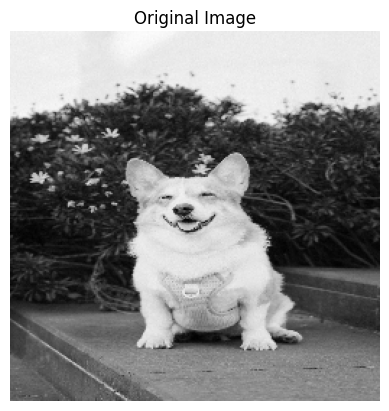

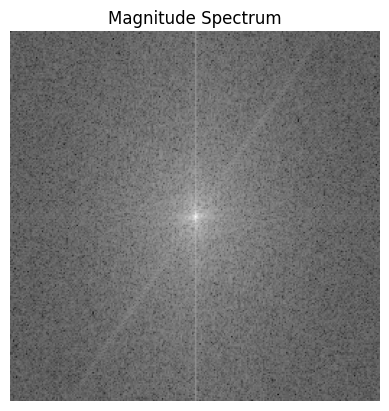

In [ ]:
# LAB 5 - Frequency Domain Processing

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from ipywidgets import interact, IntSlider

img = cv2.imread('/content/Lab5.jpg', 0)
img = cv2.resize(img, (256,256))

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# FFT
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude = 20*np.log(np.abs(fshift)+1)

plt.imshow(magnitude, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis('off')
plt.show()

In [ ]:
def ideal_lpf(D0=30):

    rows, cols = img.shape
    crow, ccol = rows//2, cols//2

    mask = np.zeros((rows, cols))

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            if D <= D0:
                mask[u,v] = 1

    filtered = fshift * mask
    img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))

    plt.imshow(img_back, cmap='gray')
    plt.title("Low Pass Filtered")
    plt.axis('off')
    plt.show()


interact(ideal_lpf, D0=IntSlider(min=10, max=100, step=10, value=30))

interactive(children=(IntSlider(value=30, description='D0', min=10, step=10), Output()), _dom_classes=('widget…

<function __main__.ideal_lpf(D0=30)>

In [ ]:
def ideal_hpf(D0=30):

    rows, cols = img.shape
    crow, ccol = rows//2, cols//2

    mask = np.ones((rows, cols))

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            if D <= D0:
                mask[u,v] = 0

    filtered = fshift * mask
    img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))

    plt.imshow(img_back, cmap='gray')
    plt.title("High Pass Filtered")
    plt.axis('off')
    plt.show()


interact(ideal_hpf, D0=IntSlider(min=10, max=100, step=10, value=30))

interactive(children=(IntSlider(value=30, description='D0', min=10, step=10), Output()), _dom_classes=('widget…

<function __main__.ideal_hpf(D0=30)>

In [ ]:
def butterworth_lpf(D0=30, n=2):

    rows, cols = img.shape
    crow, ccol = rows//2, cols//2

    H = np.zeros((rows, cols))

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            H[u,v] = 1 / (1 + (D/D0)**(2*n))

    F = np.fft.fftshift(np.fft.fft2(img))
    G = F * H

    img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(H, cmap='gray')
    plt.title("Butterworth LPF Mask")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img_back, cmap='gray')
    plt.title(f"D0={D0}, n={n}")
    plt.axis('off')

    plt.show()


interact(butterworth_lpf,
         D0=IntSlider(min=10, max=100, step=10, value=30),
         n=IntSlider(min=1, max=5, step=1, value=2))

interactive(children=(IntSlider(value=30, description='D0', min=10, step=10), IntSlider(value=2, description='…

<function __main__.butterworth_lpf(D0=30, n=2)>

In [ ]:
def homomorphic_filter(D0=30, gammaL=0.5, gammaH=2):

    img_log = np.log1p(np.array(img, dtype="float"))

    F = np.fft.fftshift(np.fft.fft2(img_log))

    rows, cols = img.shape
    crow, ccol = rows//2, cols//2

    H = np.zeros((rows, cols))

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            H[u,v] = (gammaH - gammaL)*(1 - np.exp(-(D**2)/(2*(D0**2)))) + gammaL

    G = F * H
    img_back = np.real(np.fft.ifft2(np.fft.ifftshift(G)))

    img_exp = np.expm1(img_back)
    img_exp = np.uint8(np.clip(img_exp, 0, 255))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img_exp, cmap='gray')
    plt.title("Homomorphic Filtered")
    plt.axis('off')

    plt.show()


interact(homomorphic_filter,
         D0=IntSlider(min=10, max=100, step=10, value=30))

interactive(children=(IntSlider(value=30, description='D0', min=10, step=10), FloatSlider(value=0.5, descripti…

<function __main__.homomorphic_filter(D0=30, gammaL=0.5, gammaH=2)>